<a href="https://colab.research.google.com/github/yogeshkachhwaha32-debug/ML-PROJECT/blob/main/DLaasignment28_3_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

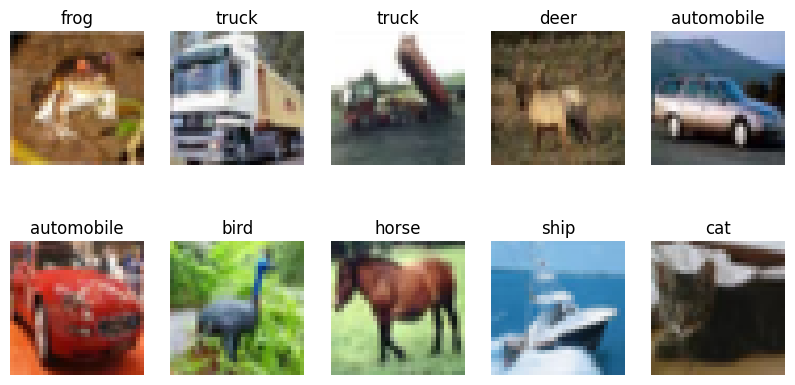

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.show()

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
history_cnn = cnn_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 51ms/step - accuracy: 0.3954 - loss: 1.6474 - val_accuracy: 0.5372 - val_loss: 1.2944
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 48ms/step - accuracy: 0.5270 - loss: 1.3226 - val_accuracy: 0.5814 - val_loss: 1.1647
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.5784 - loss: 1.1933 - val_accuracy: 0.6350 - val_loss: 1.0264
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.6109 - loss: 1.1064 - val_accuracy: 0.6522 - val_loss: 0.9741
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.6326 - loss: 1.0411 - val_accuracy: 0.6810 - val_loss: 0.9311
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.6523 - loss: 0.9822 - val_accuracy: 0.6820 - val_loss: 0.9173
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.6678 - loss: 0.9355 - val_accuracy: 0.6872 - val_loss: 0.9300
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.6846 -

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test)
print("CNN Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6902 - loss: 0.9051
CNN Accuracy: 0.6901999711990356


In [ ]:
x_train_lstm = x_train.reshape(-1, 32, 32*3)
x_test_lstm = x_test.reshape(-1, 32, 32*3)

In [ ]:
lstm_model = models.Sequential([
    layers.LSTM(64, input_shape=(32, 96)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

In [ ]:
history_lstm = lstm_model.fit(
    x_train_lstm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.3269 - loss: 1.8336 - val_accuracy: 0.3828 - val_loss: 1.6977
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.4158 - loss: 1.6088 - val_accuracy: 0.4274 - val_loss: 1.5769
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.4537 - loss: 1.5082 - val_accuracy: 0.4640 - val_loss: 1.4611
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.4781 - loss: 1.4451 - val_accuracy: 0.4808 - val_loss: 1.4128
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.4968 - loss: 1.3917 - val_accuracy: 0.4842 - val_loss: 1.4101
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.5125 - loss: 1.3514 - val_accuracy: 0.5062 - val_loss: 1.3614
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.5257 - loss: 1.3153 - val_accuracy: 0.5106 - val_loss: 1.3684
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.5370 -

# confusion matrix

In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(x_test_lstm, y_test)
print("LSTM Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5330 - loss: 1.3016
LSTM Accuracy: 0.5329999923706055


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step


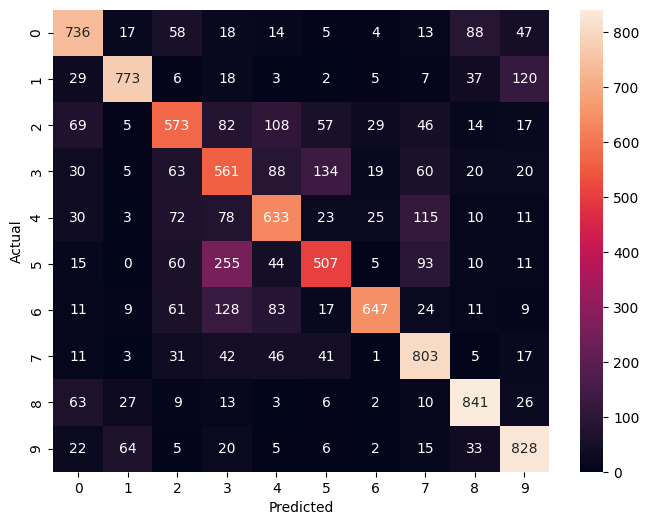

In [ ]:

y_pred = cnn_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

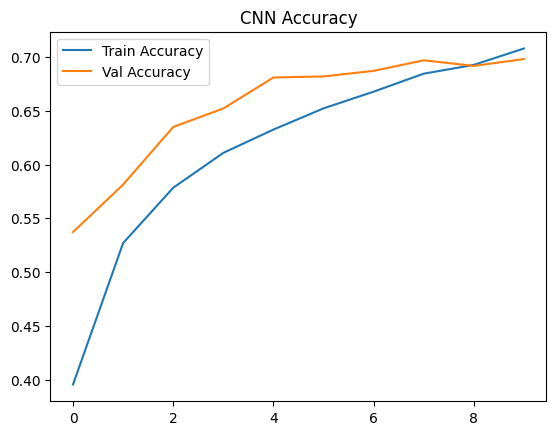

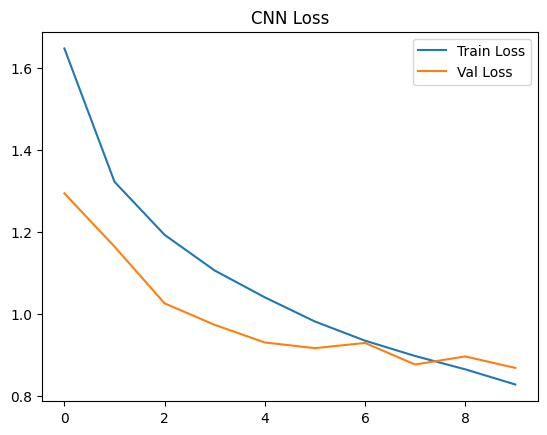

In [ ]:
# Accuracy graph
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

# Loss graph
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("CNN Loss")
plt.show()

Classificatipn Report


In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.72      0.74      0.73      1000
           1       0.85      0.77      0.81      1000
           2       0.61      0.57      0.59      1000
           3       0.46      0.56      0.51      1000
           4       0.62      0.63      0.62      1000
           5       0.64      0.51      0.56      1000
           6       0.88      0.65      0.74      1000
           7       0.68      0.80      0.73      1000
           8       0.79      0.84      0.81      1000
           9       0.75      0.83      0.79      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



In [ ]:
from sklearn.metrics import roc_curve, auc

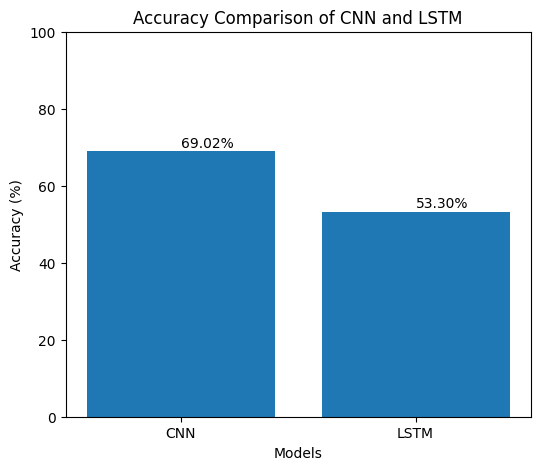

In [ ]:
import matplotlib.pyplot as plt

# Final test accuracies
cnn_accuracy = cnn_acc * 100
lstm_accuracy = lstm_acc * 100

models = ['CNN', 'LSTM']
accuracies = [cnn_accuracy, lstm_accuracy]

plt.figure(figsize=(6,5))
plt.bar(models, accuracies)
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Accuracy Comparison of CNN and LSTM")
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%")

plt.show()

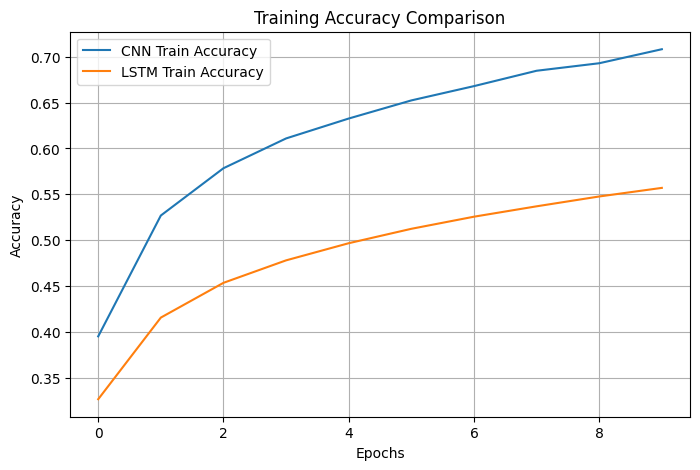

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()